# 6. Hình và bảng cho báo cáo

Xuất artifact cuối cho báo cáo LaTeX: **2 hình** (`figures/report/`) và 3 bảng
(`tables/report_*.csv` kèm bản `.tex` để `\input` thẳng vào báo cáo).

Notebook này **không tính lại bất kỳ con số nào**. Nó gọi `final_analysis` để sinh/đọc các bảng đã
chốt rồi chỉ trình bày lại - giữ đúng nguyên tắc một nguồn số duy nhất của notebook 08.

## 6.1. Thiết lập môi trường

In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().parent  # notebooks/ -> gốc dự án
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

FIG_DIR = project_root / "figures" / "report"
FIG_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from IPython.display import Image

from src import final_analysis, metrics

# Bảng màu dùng chung cho cả hai hình trong báo cáo, để chúng đọc như một hệ thống.
# Lấy nguyên từ bảng màu tham chiếu, không tự pha màu.
# Hình đi vào PDF in trên giấy trắng, nên "nền biểu đồ" ở đây là trắng giấy chứ
# không phải #fcfcfb của bảng màu gốc (vốn dành cho trang web có nền lót riêng).
# Để #fcfcfb thì hình hiện thành một ô xám trên trang, lệch với hình calibration
# do src/final_analysis.py sinh. Thang màu đã được chấm lại trên nền trắng.
SURFACE, INK, INK_2, MUTED = "#ffffff", "#0b0b0b", "#52514e", "#898781"
GRID, AXIS = "#e1e0d9", "#c3c2b7"
SERIES_1 = "#2a78d6"          # slot 1 - dùng khi hình chỉ có một chuỗi
SERIES_FILL = "#cde2fb"       # bậc nhạt nhất cùng sắc, để tô nền hộp của XGBoost
NEUTRAL_EDGE, NEUTRAL_FILL = "#7f8f9e", "#e8eef6"

# Tên mô hình dài làm nhãn trục x phải xoay nghiêng, vốn là thứ khiến hình khó
# đọc. Ngắt dòng thay cho xoay: nhãn vẫn nằm ngang, đọc thẳng.
TWO_LINE = {
    "Random Forest": "Random\nForest",
    "Logistic Regression": "Logistic\nRegression",
    "Decision Tree": "Decision\nTree",
    "Naive Bayes": "Naive\nBayes",
}

# Naive Bayes (log loss 2.211) cách nhóm còn lại (0.38 - 0.66) một khoảng lớn hơn
# toàn bộ khoảng cách giữa 5 mô hình kia cộng lại. Cả hai hình đều phải xử lý
# riêng trường hợp này, nên đặt tên ở một chỗ.
OUTLIER_MODEL = "Naive Bayes"


def strip_spines(ax, keep=()):
    """Ẩn khung trục; cạnh nào giữ lại thì vẽ mảnh và lùi về sau."""
    for side in ("top", "right", "left", "bottom"):
        ax.spines[side].set_visible(side in keep)
        if side in keep:
            ax.spines[side].set_color(AXIS)
            ax.spines[side].set_linewidth(0.8)


def axis_break(ax_upper, ax_lower):
    """Vẽ dấu ngắt chéo giữa hai panel chồng nhau dùng chung một trục y."""
    d = 0.6
    mark = dict(marker=[(-1, -d), (1, d)], markersize=7, linestyle="none",
                color=AXIS, mec=AXIS, mew=1.0, clip_on=False)
    ax_upper.plot([0, 1], [0, 0], transform=ax_upper.transAxes, **mark)
    ax_lower.plot([0, 1], [1, 1], transform=ax_lower.transAxes, **mark)


# Hình rộng 8 inch nhưng \linewidth của báo cáo chỉ ~6.4 inch, nên LaTeX thu nhỏ
# khoảng 0.8 lần. Đặt cỡ chữ gốc 12pt để sau khi thu nhỏ còn ~9.5pt, ngang cỡ chữ
# thân bài - chữ trong hình nhỏ hơn hẳn chữ xung quanh là dấu hiệu hình bị ép.
# Mọi cỡ chữ bên dưới khai báo tương đối ("large", "small") để chỉ cần sửa một chỗ.
plt.rcParams.update({
    "figure.facecolor": SURFACE,
    "axes.facecolor": SURFACE,
    "savefig.facecolor": SURFACE,
    "font.size": 12,
})

## 6.2. Nạp artifact đã chốt

`write_inference_outputs()` sinh lại `tables/pairwise_comparisons.csv` và
`tables/assumption_checks.csv` từ `results/scores_all.csv`, nên hai bảng luôn đồng bộ với bảng điểm.
Các bảng calibration đọc thẳng từ đầu ra của `run_calibration_analysis()` (mục 7.7 notebook 08).

In [3]:
scores = pd.read_csv(project_root / "results" / "scores_all.csv")
final_analysis.validate_scores(scores)

pairwise, assumptions = final_analysis.write_inference_outputs(project_root, scores)
calibration = pd.read_csv(project_root / final_analysis.CALIBRATION_METRICS_TABLE)
bin_sensitivity = pd.read_csv(project_root / final_analysis.CALIBRATION_SENSITIVITY_TABLE)

print("scores:", scores.shape, "| pairwise:", pairwise.shape, "| assumptions:", assumptions.shape)

scores: (30, 5) | pairwise: (5, 15) | assumptions: (5, 13)


## 6.3. Bảng 1 - So sánh 6 mô hình

`mean ± std` qua 5 fold cho cả 3 chỉ số, sắp theo log loss (chỉ số chính).

In [4]:
summary = metrics.summarize_scores(scores)
summary = summary.reindex(summary[("log_loss", "mean")].sort_values().index)

table1 = pd.DataFrame({
    "Mô hình": summary.index,
    **{
        label: [f"{summary.loc[m, (col, 'mean')]:.3f} ± {summary.loc[m, (col, 'std')]:.3f}"
                for m in summary.index]
        for label, col in [("Log loss", "log_loss"), ("Accuracy", "accuracy"),
                           ("Macro-F1", "macro_f1")]
    },
})
table1.to_csv(project_root / "tables" / "report_model_comparison.csv", index=False)
table1

,Mô hình,Log loss,Accuracy,Macro-F1
0,XGBoost,0.382 ± 0.007,0.850 ± 0.006,0.640 ± 0.032
1,Random Forest,0.406 ± 0.006,0.848 ± 0.007,0.569 ± 0.008
2,Logistic Regression,0.441 ± 0.009,0.833 ± 0.005,0.558 ± 0.014
3,Decision Tree,0.474 ± 0.011,0.830 ± 0.007,0.529 ± 0.008
4,KNN,0.660 ± 0.055,0.814 ± 0.009,0.515 ± 0.010
5,Naive Bayes,2.211 ± 0.217,0.589 ± 0.030,0.466 ± 0.019


## 6.4. Hình 1 - Phân bố log loss theo fold

Box plot cho thấy thứ mà cột trung bình che mất: **độ ổn định giữa các fold**. Mỗi hộp là phân bố 5
giá trị log loss của một mô hình. Hộp hẹp nghĩa là mô hình cho kết quả nhất quán bất kể chia fold thế
nào; hộp rộng nghĩa là điểm số phụ thuộc nhiều vào việc rơi trúng fold nào - và đó chính là lý do
phải kiểm định ghép cặp thay vì so hai con số trung bình. Mỗi chấm là một fold: với `n = 5` thì vẽ
luôn từng điểm là trung thực hơn là để tứ phân vị của 5 số tự tóm tắt.

**Naive Bayes xử lý bằng trục y bị ngắt, không phải panel rời.** Bản trước tách nó sang một panel
thứ hai đặt cạnh bên. Hệ quả là hình có hai trục x (hai hàng tên mô hình), hai trục y không cùng
thang và không cùng nhãn, cộng thêm một tiêu đề chung và hai tiêu đề con - năm khối chữ cho một
biểu đồ. Ở đây vẫn là **một trục x duy nhất** với sáu mô hình xếp theo thứ hạng, chỉ khoảng trống
0.8 - 1.8 của trục y (không có dữ liệu nào rơi vào) bị cắt bỏ, đánh dấu bằng ký hiệu ngắt trục
tiêu chuẩn. Tên mô hình vì thế xuất hiện đúng một lần và không phải xoay nghiêng.

> Hình này thay luôn vai trò của biểu đồ chấm `mean ± std` từng có ở bản trước. Biểu đồ đó vẽ lại
> đúng cột log loss của Bảng 1 nằm ngay phía trên nó, trong khi box plot chứa toàn bộ thông tin đó
> (vị trí, thứ hạng, khoảng cách) và thêm phân bố từng fold - nên giữ cả hai là in một thông tin
> ba lần.

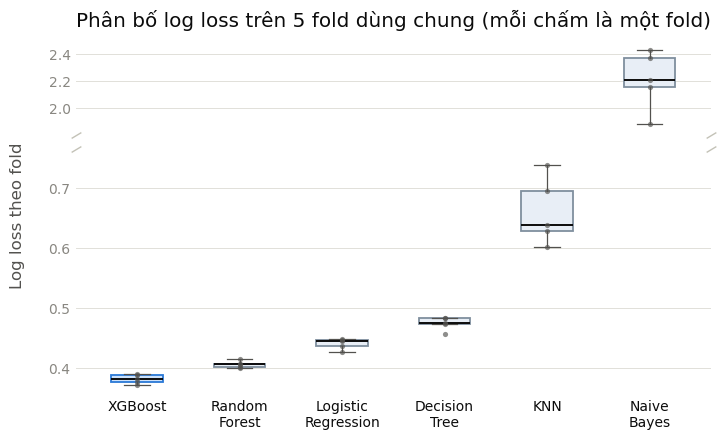

In [5]:
models_ordered = summary.index.tolist()          # đã sắp theo log loss tăng dần
positions = np.arange(1, len(models_ordered) + 1)
values = [scores.loc[scores["model"] == m, "log_loss"].to_numpy() for m in models_ordered]

# Hai panel chồng nhau = MỘT trục y bị cắt bỏ đoạn 0.8 - 1.8 vốn không có dữ liệu.
# Cả hai vẽ đủ 6 hộp; mỗi panel chỉ khác nhau ở ylim, nên trục x dùng chung.
fig, (ax_top, ax_bot) = plt.subplots(
    2, 1, sharex=True, figsize=(8.2, 4.6),
    gridspec_kw={"height_ratios": [1, 2.6], "hspace": 0.08})

for ax in (ax_top, ax_bot):
    bp = ax.boxplot(values, positions=positions, widths=0.5, patch_artist=True,
                    medianprops=dict(color=INK, linewidth=1.4),
                    whiskerprops=dict(color=INK_2, linewidth=0.9),
                    capprops=dict(color=INK_2, linewidth=0.9),
                    flierprops=dict(marker=""), zorder=2)
    for patch, name in zip(bp["boxes"], models_ordered):
        is_ref = name == final_analysis.REFERENCE_MODEL
        patch.set_facecolor(SERIES_FILL if is_ref else NEUTRAL_FILL)
        patch.set_edgecolor(SERIES_1 if is_ref else NEUTRAL_EDGE)
        patch.set_linewidth(1.3)
    for pos, vals in zip(positions, values):
        ax.scatter(np.full(len(vals), pos), vals, s=14, color=INK_2,
                   alpha=0.65, zorder=3, linewidths=0)
    ax.grid(True, axis="y", linewidth=0.7, color=GRID, zorder=0)
    ax.set_axisbelow(True)
    ax.tick_params(colors=MUTED, labelsize="small", length=0)
    strip_spines(ax)

ax_top.set_ylim(1.80, 2.50)
ax_top.set_yticks([2.0, 2.2, 2.4])
ax_top.tick_params(bottom=False)
ax_bot.set_ylim(0.355, 0.765)
ax_bot.set_yticks([0.4, 0.5, 0.6, 0.7])
axis_break(ax_top, ax_bot)

ax_bot.set_xticks(positions)
ax_bot.set_xticklabels([TWO_LINE.get(m, m) for m in models_ordered], fontsize="small")
for lbl in ax_bot.get_xticklabels():
    lbl.set_color(INK)
ax_bot.set_xlim(0.4, len(models_ordered) + 0.6)
fig.supylabel("Log loss theo fold", fontsize="medium", color=INK_2, x=0.045)
ax_top.set_title("Phân bố log loss trên 5 fold dùng chung (mỗi chấm là một fold)",
                 fontsize="large", color=INK, loc="left", x=0, pad=10)

fig.savefig(FIG_DIR / "fig1_logloss_by_fold.png", dpi=200, bbox_inches="tight")
plt.show()

# Trục bị ngắt chỉ hợp lệ nếu khoảng cắt bỏ thật sự trống và mọi fold đều hiện ra.
gap_lo, gap_hi = ax_bot.get_ylim()[1], ax_top.get_ylim()[0]
all_values = scores["log_loss"].to_numpy()
assert not ((all_values > gap_lo) & (all_values < gap_hi)).any(), "có fold rơi vào khoảng cắt"
assert all_values.min() > ax_bot.get_ylim()[0] and all_values.max() < ax_top.get_ylim()[1]

## 6.5. Bảng 2 - Tóm tắt kiểm định

Gộp phần kiểm định ghép cặp (mục 7.4 notebook 08) với phần chọn kiểm định chính (mục 7.5): chênh
lệch trung bình, CI 95%, kiểm định chính do Shapiro-Wilk chọn, p thô và p sau Bonferroni.

In [6]:
merged = pairwise.merge(
    assumptions[["comparator_model", "shapiro_p_value", "primary_test",
                 "primary_p_value_raw", "primary_p_value_adjusted"]],
    on="comparator_model",
)
table2 = pd.DataFrame({
    "So với": merged["comparator_model"],
    "Chênh lệch TB": merged["mean_difference"].map("{:.4f}".format),
    "CI 95%": [f"[{low:.4f}, {high:.4f}]"
               for low, high in zip(merged["ci_95_low"], merged["ci_95_high"])],
    "Shapiro p": merged["shapiro_p_value"].map("{:.4f}".format),
    "Kiểm định chính": merged["primary_test"].map(
        {"paired_t_test": "paired t-test", "wilcoxon": "Wilcoxon"}),
    "p thô": merged["primary_p_value_raw"].map("{:.5f}".format),
    "p Bonferroni": merged["primary_p_value_adjusted"].map("{:.5f}".format),
    "Kết luận": np.where(merged["primary_p_value_adjusted"] <= final_analysis.ALPHA,
                         "XGBoost tốt hơn", "Chưa đủ bằng chứng"),
})
table2.to_csv(project_root / "tables" / "report_significance.csv", index=False)
table2

,So với,Chênh lệch TB,CI 95%,Shapiro p,Kiểm định chính,p thô,p Bonferroni,Kết luận
0,Random Forest,-0.0240,"[-0.0287, -0.0192]",0.4627,paired t-test,0.00015,0.00075,XGBoost tốt hơn
1,Logistic Regression,-0.0586,"[-0.0673, -0.0498]",0.0142,Wilcoxon,0.06250,0.31250,Chưa đủ bằng chứng
2,Decision Tree,-0.0923,"[-0.1035, -0.0812]",0.5161,paired t-test,0.00002,0.00011,XGBoost tốt hơn
3,KNN,-0.2783,"[-0.3496, -0.2071]",0.3438,paired t-test,0.00041,0.00205,XGBoost tốt hơn
4,Naive Bayes,-1.8287,"[-2.0919, -1.5656]",0.5702,paired t-test,0.00004,0.00021,XGBoost tốt hơn


## 6.6. Hình 2 - Khoảng tin cậy 95% của chênh lệch ghép cặp

Hình chủ đạo của phần kết quả. Mỗi dòng là một phép so sánh `XGBoost - mô hình khác` trên log loss:
điểm là chênh lệch trung bình, thanh ngang là CI 95%. Vạch dọc `0` là mốc "không khác biệt".

**Điểm đặc/rỗng mã hóa kết luận kiểm định.** Đây không phải trang trí: CI của Logistic Regression
nằm trọn bên trái vạch 0, nhìn thì tưởng đã có ý nghĩa, nhưng Shapiro-Wilk bác bỏ giả định chuẩn
nên kiểm định chính chuyển sang Wilcoxon, mà với `n = 5` thì p hai phía nhỏ nhất Wilcoxon trả về
được là .0625 - vượt ngưỡng trước cả khi nhìn dữ liệu. Không có dấu này thì hình mâu thuẫn với
Bảng 2 ngay bên trên.

**Trục x tuyến tính, và Naive Bayes bị bỏ khỏi hình.** Bản trước dùng `symlog` để nhét cả chênh
lệch -1.83 của Naive Bayes vào cùng một trục. Cái giá phải trả lớn hơn nhiều so với chỗ tiết kiệm
được: trên trục phi tuyến, **bề rộng vẽ ra của một CI không còn tỉ lệ với bề rộng thật**, nên CI
của Random Forest (rộng .0095) trông to ngang CI của Decision Tree (rộng .0223). Mà so sánh độ
chính xác giữa các dòng lại đúng là việc mà forest plot sinh ra để làm. Trục tuyến tính trả lại
tính so sánh được; Naive Bayes vốn không phải đối thủ cạnh tranh nên chỉ cần ghi số ở chú thích
chân hình và tra Bảng 2.

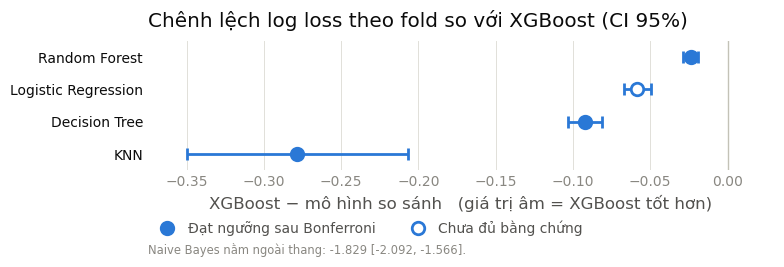

In [7]:
forest = pairwise.merge(
    assumptions[["comparator_model", "primary_test", "primary_p_value_adjusted"]],
    on="comparator_model",
).set_index("comparator_model")
forest["significant"] = forest["primary_p_value_adjusted"] <= final_analysis.ALPHA

# Giữ đúng thứ tự của Bảng 2 (theo log loss tăng dần) để hình và bảng đọc song song.
shown = [m for m in summary.index if m not in (final_analysis.REFERENCE_MODEL, OUTLIER_MODEL)]
off_scale = forest.loc[OUTLIER_MODEL]

fig, ax = plt.subplots(figsize=(8.0, 3.7))

# Mốc "không khác biệt" vẽ liền nét: nét đứt đọc thành "ngưỡng dự báo".
ax.axvline(0, linewidth=1.0, color=AXIS, zorder=1)

for y, name in enumerate(shown):
    row = forest.loc[name]
    ax.errorbar(
        row["mean_difference"], y,
        xerr=[[row["mean_difference"] - row["ci_95_low"]],
              [row["ci_95_high"] - row["mean_difference"]]],
        fmt="o", markersize=9, elinewidth=2.0, capsize=4,
        color=SERIES_1, ecolor=SERIES_1,
        markerfacecolor=SERIES_1 if row["significant"] else SURFACE,
        markeredgecolor=SERIES_1, markeredgewidth=2.0, zorder=3,
    )

ax.set_yticks(range(len(shown)))
ax.set_yticklabels(shown)
ax.set_ylim(len(shown) - 0.5, -0.5)     # dòng đầu của Bảng 2 nằm trên cùng
ax.set_xlim(-0.375, 0.03)
ax.set_xlabel("XGBoost − mô hình so sánh   (giá trị âm = XGBoost tốt hơn)",
              fontsize="medium", color=INK_2)
ax.set_title("Chênh lệch log loss theo fold so với XGBoost (CI 95%)",
             fontsize="large", color=INK, loc="left", x=0, pad=10)
ax.grid(True, axis="x", linewidth=0.7, color=GRID, zorder=0)
ax.set_axisbelow(True)
ax.tick_params(colors=MUTED, labelsize="small", length=0)
for lbl in ax.get_yticklabels():
    lbl.set_color(INK)
strip_spines(ax)

# Chú giải xuống dưới trục thành một hàng ngang: đặt trong lòng hình thì nó chen
# vào vùng dữ liệu và bị đọc nhầm thành nhãn của một dòng.
ax.legend(
    handles=[
        Line2D([], [], marker="o", linestyle="none", markersize=9, color=SERIES_1,
               markerfacecolor=SERIES_1, markeredgecolor=SERIES_1, markeredgewidth=2.0,
               label="Đạt ngưỡng sau Bonferroni"),
        Line2D([], [], marker="o", linestyle="none", markersize=9, color=SERIES_1,
               markerfacecolor=SURFACE, markeredgecolor=SERIES_1, markeredgewidth=2.0,
               label="Chưa đủ bằng chứng"),
    ],
    loc="upper left", bbox_to_anchor=(0, -0.34), ncol=2, frameon=False,
    fontsize="small", labelcolor=INK_2, handletextpad=0.5, columnspacing=2.0,
    borderaxespad=0,
)
ax.text(0, -0.56,
        f"Naive Bayes nằm ngoài thang: {off_scale['mean_difference']:.3f} "
        f"[{off_scale['ci_95_low']:.3f}, {off_scale['ci_95_high']:.3f}].",
        transform=ax.transAxes, fontsize="x-small", color=MUTED, ha="left", va="top")

fig.tight_layout()
fig.savefig(FIG_DIR / "fig2_paired_ci_forest.png", dpi=200, bbox_inches="tight")
plt.show()

# Trục tuyến tính chỉ trung thực nếu mọi CI được vẽ đều lọt trong xlim.
lo, hi = ax.get_xlim()
assert all(lo < forest.loc[m, "ci_95_low"] and forest.loc[m, "ci_95_high"] < hi
           for m in shown), "có CI bị cắt cụt - chỉnh lại xlim"

## 6.7. Bảng 3 - Calibration của mô hình tốt nhất

Reliability diagram đã được `run_calibration_analysis()` lưu sẵn ở
`figures/calibration/xgboost_reliability_diagram.png`; ở đây chỉ hiển thị lại, **không vẽ lại**, để
báo cáo và notebook 08 dùng đúng một file hình. Hình đó thuộc quyền quản lý của notebook 08 nên
không nằm trong số 2 hình mà notebook này chịu trách nhiệm xuất.

Bảng 3 ghép chỉ số calibration chính với bảng độ nhạy theo số bin - ECE phụ thuộc cách chia bin nên
báo cáo một con số duy nhất là chưa đủ.

In [8]:
row = calibration.iloc[0]
table3 = pd.DataFrame({
    "Số bin": bin_sensitivity["n_bins"],
    "Top-label ECE": bin_sensitivity["top_label_ece"].map("{:.4f}".format),
    "Macro classwise ECE": bin_sensitivity["macro_classwise_ece"].map("{:.4f}".format),
})
table3["Brier đa lớp"] = f"{row['multiclass_brier_score']:.4f}"
table3["Ghi chú"] = np.where(bin_sensitivity["n_bins"] == row["n_bins"],
                             "bin dùng trong báo cáo", "")
table3.to_csv(project_root / "tables" / "report_calibration.csv", index=False)

print(f"Mô hình: {row['model']} | n = {int(row['n_samples'])} | thứ tự lớp: {row['class_order']}")
table3

Mô hình: XGBoost | n = 9600 | thứ tự lớp: C,CL,D


,Số bin,Top-label ECE,Macro classwise ECE,Brier đa lớp,Ghi chú
0,5,0.0117,0.0066,0.2162,
1,10,0.0117,0.0085,0.2162,bin dùng trong báo cáo
2,15,0.0138,0.0094,0.2162,
3,20,0.0144,0.0106,0.2162,


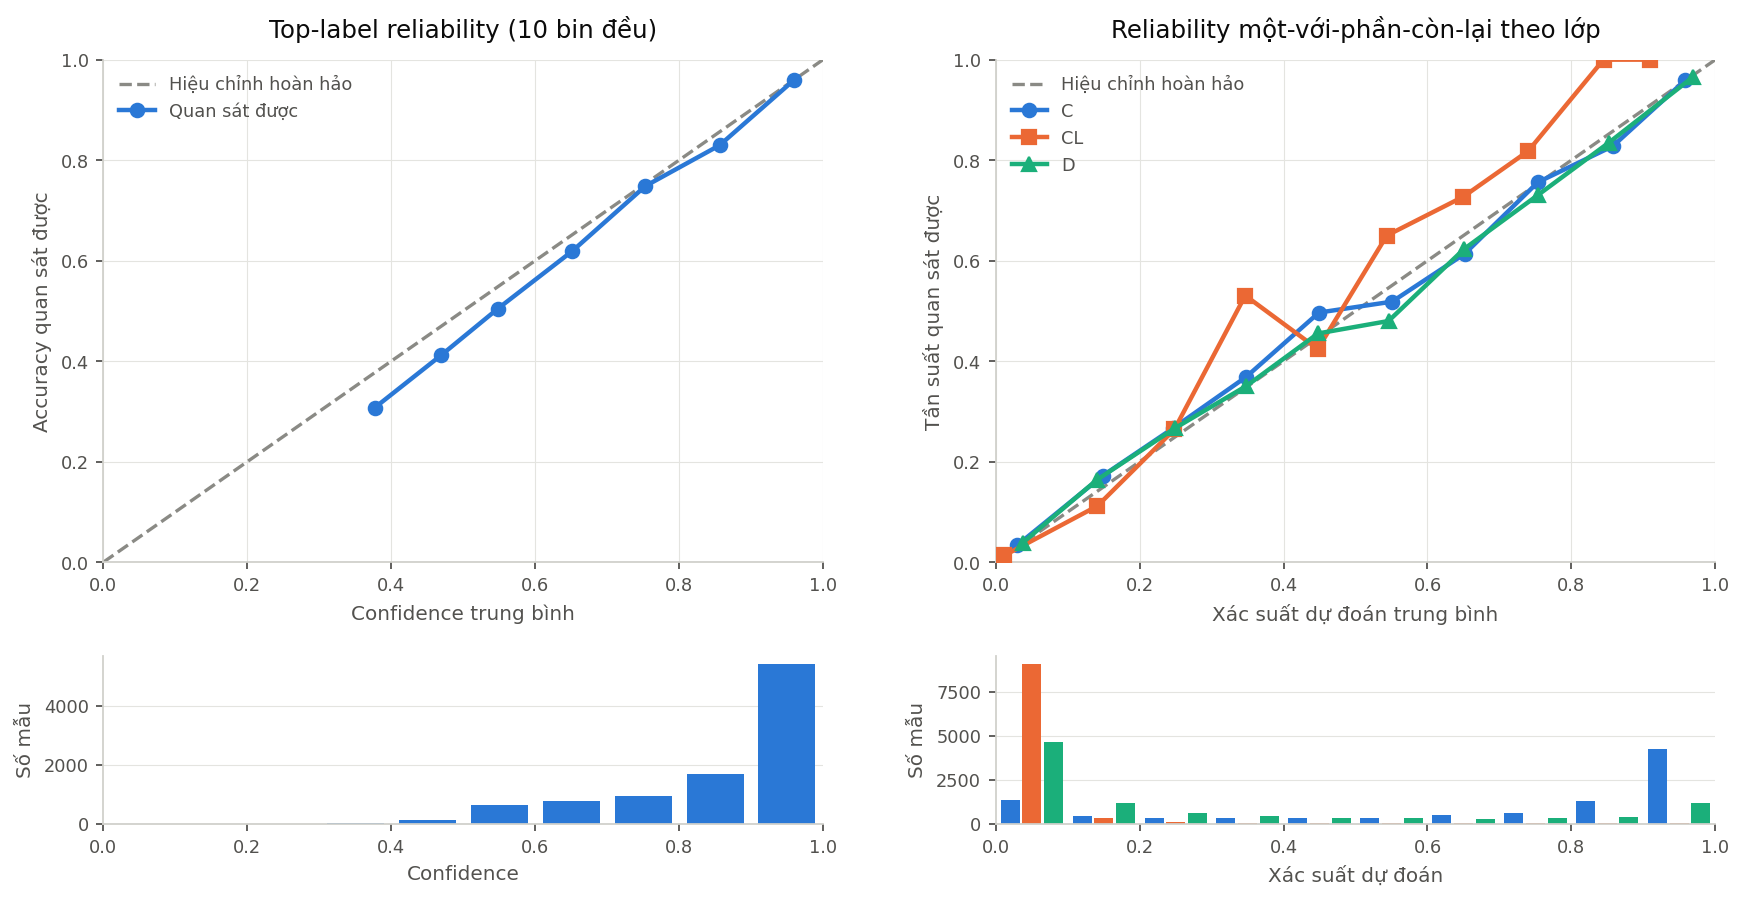

In [9]:
Image(filename=str(project_root / final_analysis.CALIBRATION_FIGURE))

## 6.8. Xuất bảng sang LaTeX

Bản `.tex` **chỉ chứa môi trường `tabular`**, cố ý không kèm `caption`/`label`: caption và label
thuộc về báo cáo - nơi quyết định cách trình bày, vị trí và số hiệu bảng - còn notebook chỉ chịu
trách nhiệm về con số. Nhờ tách vai trò như vậy, báo cáo `\input` thẳng được mà không phải gõ tay
lại số, và cũng không bị notebook áp đặt caption.

Gõ tay là nguồn sai lệch phổ biến nhất giữa code và báo cáo: số trong bảng vẫn đúng ở thời điểm gõ,
nhưng lần chạy lại phân tích tiếp theo sẽ làm chúng lệch nhau mà không có gì cảnh báo.

Lưu ý bản `.csv` và `.tex` của bảng 2 không trùng số cột: `.csv` giữ đủ 8 cột làm bản ghi đầy đủ,
`.tex` rút còn 6 cột cho vừa khổ giấy.

In [10]:
def no_lead_zero(x, digits=4):
    """.0240 thay vì 0.0240 - quy ước trình bày cho đại lượng không thể vượt 1."""
    s = f"{x:.{digits}f}"
    sign, body = ("-", s[1:]) if s.startswith("-") else ("", s)
    return sign + (body[1:] if body.startswith("0.") else body)


tex_table1 = pd.DataFrame({
    "Mô hình": summary.index,
    **{
        f"{label} ${arrow}$": [
            f"${summary.loc[m, (col, 'mean')]:.3f}\\pm{summary.loc[m, (col, 'std')]:.3f}$"
            for m in summary.index
        ]
        for label, col, arrow in [("Log loss", "log_loss", r"\downarrow"),
                                  ("Accuracy", "accuracy", r"\uparrow"),
                                  ("Macro-F1", "macro_f1", r"\uparrow")]
    },
})

tex_table2 = pd.DataFrame({
    "Comparator": merged["comparator_model"],
    r"$\bar d$": merged["mean_difference"].map(no_lead_zero),
    r"CI 95\%": [f"[{no_lead_zero(lo)},{no_lead_zero(hi)}]"
                 for lo, hi in zip(merged["ci_95_low"], merged["ci_95_high"])],
    "Shapiro p": merged["shapiro_p_value"].map(no_lead_zero),
    "p chỉnh": merged["primary_p_value_adjusted"].map(lambda v: no_lead_zero(v, 5)),
    "Kết luận": np.where(merged["primary_p_value_adjusted"] <= final_analysis.ALPHA,
                         "XGB tốt hơn", "Chưa đủ bằng chứng"),
})

# escape=False vì các ô đã chứa lệnh LaTeX cố ý ($\pm$, $\bar d$, \%); không có
# tên mô hình nào chứa ký tự đặc biệt cần thoát.
latex_tables = {
    "report_model_comparison": (tex_table1, "lccc"),
    "report_significance": (tex_table2, "lrrrrl"),
    "report_calibration": (table3, "rrrrl"),
}
for name, (frame, colfmt) in latex_tables.items():
    path = project_root / "tables" / f"{name}.tex"
    body = frame.to_latex(index=False, escape=False, column_format=colfmt)
    assert "\\begin{table}" not in body, "phải là tabular trần, không bọc table"
    path.write_text(body, encoding="utf-8")
    print("đã ghi", path.relative_to(project_root).as_posix())


đã ghi tables/report_model_comparison.tex
đã ghi tables/report_significance.tex
đã ghi tables/report_calibration.tex


## 6.9. Tổng kết artifact

In [11]:
artifacts = [
    FIG_DIR / "fig1_logloss_by_fold.png",
    FIG_DIR / "fig2_paired_ci_forest.png",
    project_root / final_analysis.CALIBRATION_FIGURE,
    project_root / "tables" / "report_model_comparison.csv",
    project_root / "tables" / "report_significance.csv",
    project_root / "tables" / "report_calibration.csv",
    project_root / "tables" / "report_model_comparison.tex",
    project_root / "tables" / "report_significance.tex",
    project_root / "tables" / "report_calibration.tex",
]
inventory = pd.DataFrame({
    "artifact": [p.relative_to(project_root).as_posix() for p in artifacts],
    "tồn tại": [p.exists() for p in artifacts],
    "KB": [round(p.stat().st_size / 1024, 1) if p.exists() else None for p in artifacts],
})
assert inventory["tồn tại"].all(), "Thiếu artifact, xem lại các mục phía trên."

# Hai hình bị loại (biểu đồ chấm mean ± std và ma trận chênh lệch theo cặp) phải
# biến mất khỏi thư mục, không để lại file mồ côi cho báo cáo lỡ trỏ vào.
retired = ["fig1_model_comparison.png", "fig3_logloss_boxplot.png",
           "fig4_pvalue_heatmap.png", "fig4_pairwise_effect_matrix.png"]
assert not [n for n in retired if (FIG_DIR / n).exists()], "còn file hình đã loại"
inventory

,artifact,tồn tại,KB
0,figures/report/fig1_logloss_by_fold.png,True,71.1
1,figures/report/fig2_paired_ci_forest.png,True,93.0
2,figures/calibration/xgboost_reliability_diagra...,True,135.4
3,tables/report_model_comparison.csv,True,0.4
4,tables/report_significance.csv,True,0.6
5,tables/report_calibration.csv,True,0.2
6,tables/report_model_comparison.tex,True,0.6
7,tables/report_significance.tex,True,0.5
8,tables/report_calibration.tex,True,0.3


## 6.10. Nhận xét

- **Hình 1** cho thấy khoảng cách log loss không đều: 5 mô hình nằm trong dải 0.38 - 0.66, riêng
  Naive Bayes 2.211 (giả định độc lập đặc trưng sai nặng với dữ liệu xét nghiệm gan tương quan cao).
  Thứ hạng giữ nguyên ở cả 5 fold, nhưng KNN và Naive Bayes dao động rộng hơn hẳn 4 mô hình đầu.
- **Hình 2** là bằng chứng trực quan mạnh nhất: cả 5 CI 95% đều nằm trọn bên trái vạch 0 - 4 CI vẽ
  trong hình, riêng Naive Bayes ghi ở chú thích chân hình vì nằm ngoài thang.
- **Bảng 2** cho thấy điểm tinh tế của bài: với Logistic Regression, CI 95% nằm dưới 0 nhưng kiểm
  định chính lại là Wilcoxon (Shapiro `p ≈ 0.014`) và `p Bonferroni = 0.3125` ⇒ kết luận cuối là
  **chưa đủ bằng chứng**. Báo cáo phải trích Bảng 2, không được chỉ trích Hình 2.
- **Bảng 3** cho thấy ECE tăng theo số bin (0.0117 → 0.0144) nhưng vẫn nhỏ ở mọi lựa chọn bin.